# Лабораторная работа 1. Линейная регрессия и факторный анализ
Датасет: California Housing Prices (Kaggle: camnugent/california-housing-prices)
Целевая переменная: median_house_value — медианная стоимость дома в квартале.

Студент: Савченко Владислав Эдуардович, АВТ-313

In [25]:
import os
import sys
import urllib.request
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

# Рабочая папка = папка со скриптом (чтобы пути не зависели от способа запуска)
try:
    os.chdir(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    pass  # запуск в Jupyter — рабочая папка уже верная

FIG = "figs/"
os.makedirs(FIG, exist_ok=True)
RES = {}

In [26]:
CSV = "housing.csv"
URL = ("https://raw.githubusercontent.com/ageron/handson-ml2/"
       "master/datasets/housing/housing.csv")
if not os.path.exists(CSV):
    print("Файл не найден, скачиваем датасет...")
    try:
        urllib.request.urlretrieve(URL, CSV)
    except Exception as e:
        sys.exit(f"Не удалось скачать датасет ({e}). "
                 f"Скачайте вручную по ссылке {URL} и положите файл рядом со скриптом.")

df = pd.read_csv(CSV)
print("Размер датасета:", df.shape)
print(df.head())
print(df.info())
print(df.describe().T)
RES["shape_raw"] = list(df.shape)
RES["describe"] = df.describe().T.round(2).to_dict()

Размер датасета: (20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.DataFrame'>
RangeIndex: 20640 e

In [27]:
na = df.isna().sum()
print("Пропуски:\n", na[na > 0])
RES["na"] = na[na > 0].to_dict()
print("Дубликаты:", df.duplicated().sum())
RES["dupl"] = int(df.duplicated().sum())
RES["cat_counts"] = df["ocean_proximity"].value_counts().to_dict()

Пропуски:
 total_bedrooms    207
dtype: int64
Дубликаты: 0


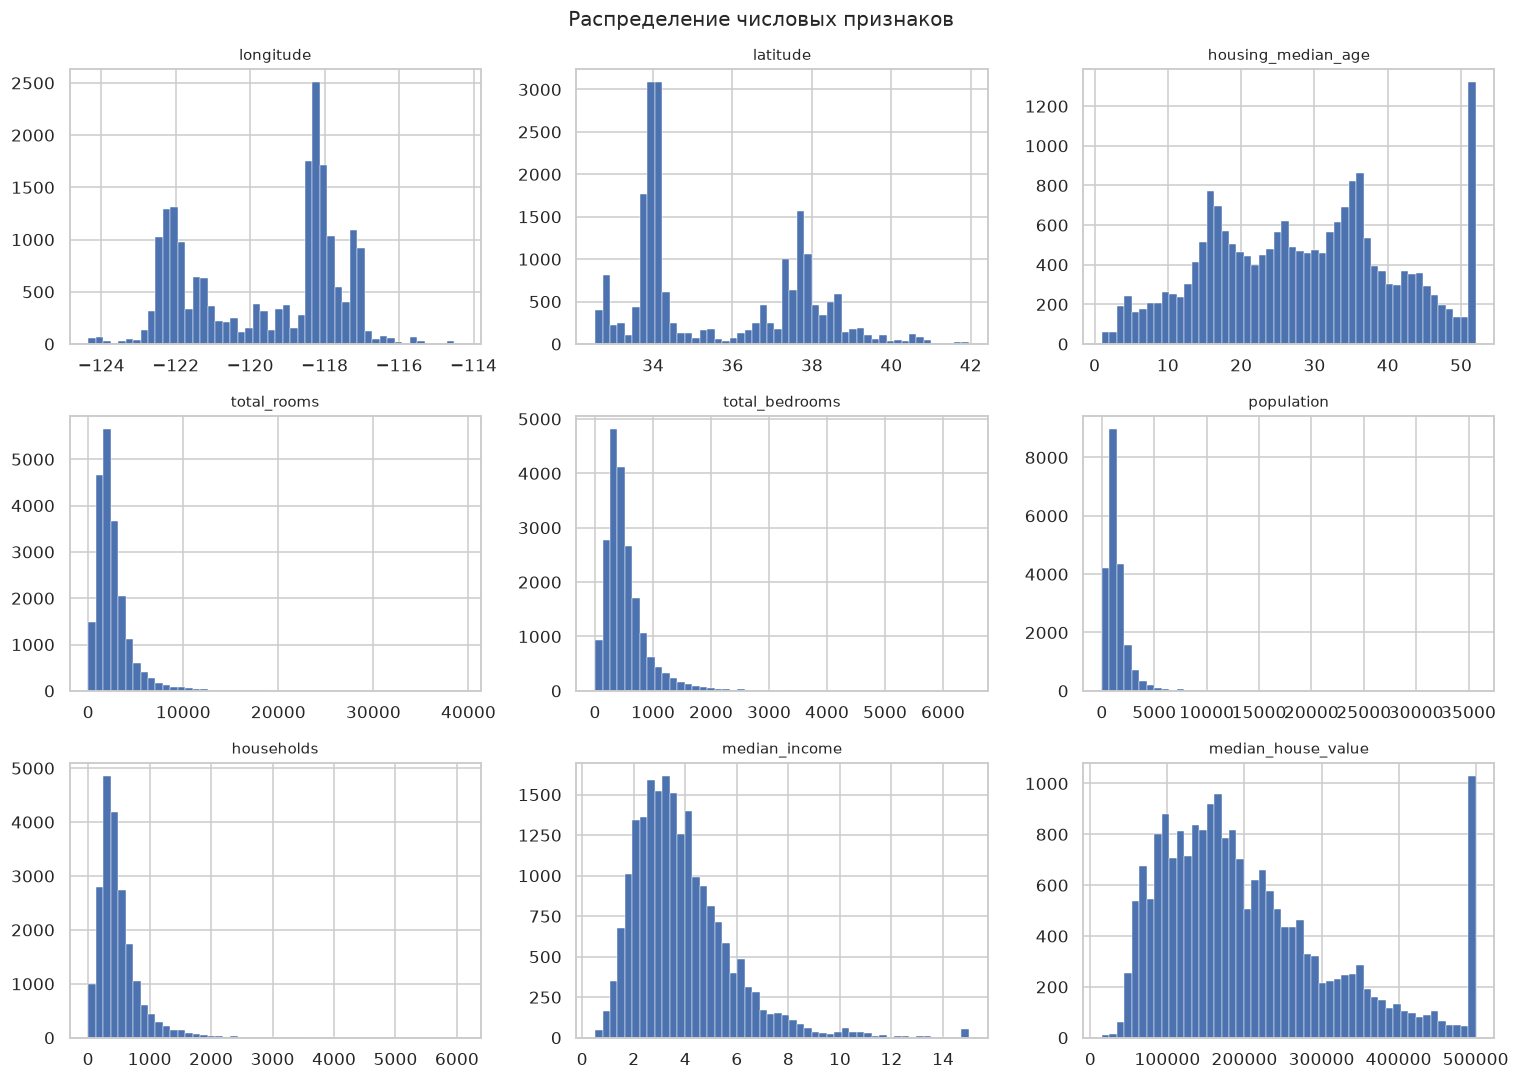

In [28]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.ravel(), num_cols):
    ax.hist(df[c].dropna(), bins=50, color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.set_title(c, fontsize=10)
fig.suptitle("Распределение числовых признаков", fontsize=13)
fig.tight_layout()
fig.savefig(FIG + "01_hist.png", bbox_inches="tight")
plt.show()

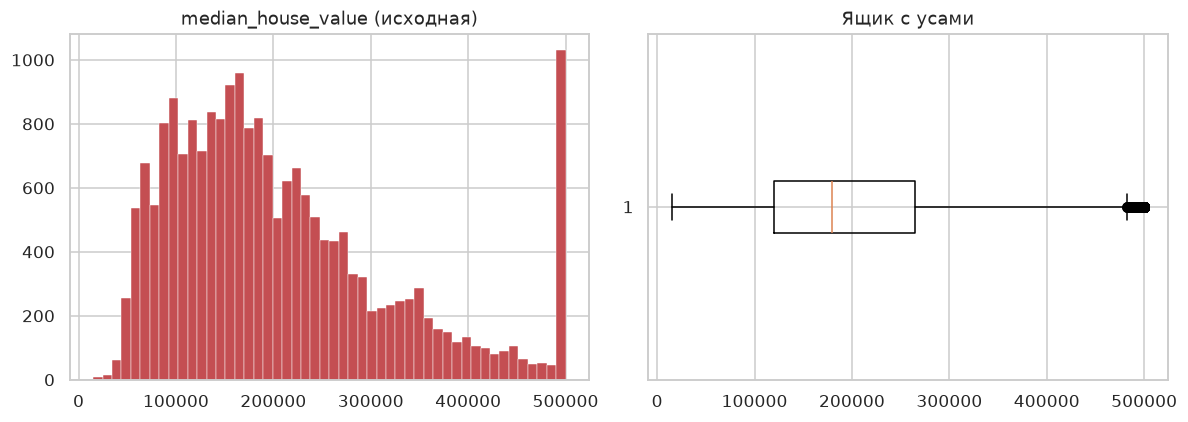

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["median_house_value"], bins=50, color="#C44E52", edgecolor="white", linewidth=0.3)
axes[0].set_title("median_house_value (исходная)")
axes[1].boxplot(df["median_house_value"], vert=False)
axes[1].set_title("Ящик с усами")
fig.tight_layout()
fig.savefig(FIG + "02_target.png", bbox_inches="tight")
plt.show()

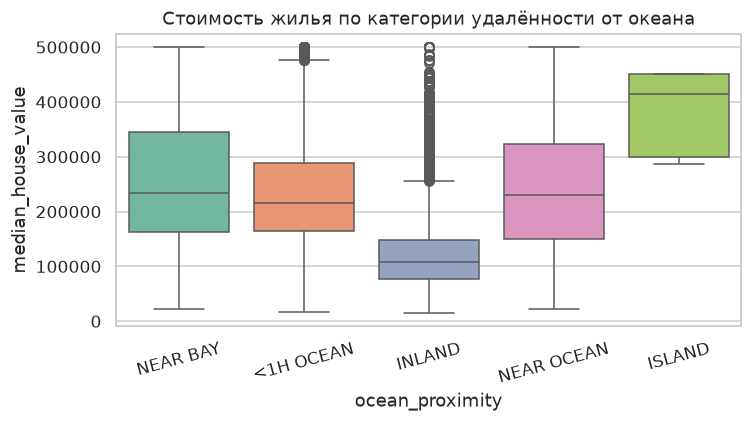

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", ax=ax, palette="Set2")
ax.set_title("Стоимость жилья по категории удалённости от океана")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIG + "03_cat.png", bbox_inches="tight")
plt.show()

In [31]:
# 3.1 Удаление пропусков (207 строк в total_bedrooms — менее 1 % выборки)
df = df.dropna().reset_index(drop=True)

# 3.2 Удаление "цензурированных" наблюдений (значения обрезаны сверху на 500001)
cap = df["median_house_value"].max()
n_cap = int((df["median_house_value"] >= cap).sum())
RES["cap_value"], RES["n_cap"] = float(cap), n_cap
df = df[df["median_house_value"] < cap].reset_index(drop=True)

# 3.3 Производные признаки (нормировка на размер квартала)
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

# 3.4 Кодирование категориальной переменной (one-hot, dummy-кодирование)
df = pd.get_dummies(df, columns=["ocean_proximity"], prefix="op", drop_first=True, dtype=float)

TARGET = "median_house_value"
X = df.drop(columns=[TARGET])
y = df[TARGET]
print("Размер после предобработки:", df.shape)
print("Признаки:", list(X.columns))
RES["shape_clean"] = list(df.shape)
RES["features"] = list(X.columns)

Размер после предобработки: (19475, 16)
Признаки: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'op_INLAND', 'op_ISLAND', 'op_NEAR BAY', 'op_NEAR OCEAN']


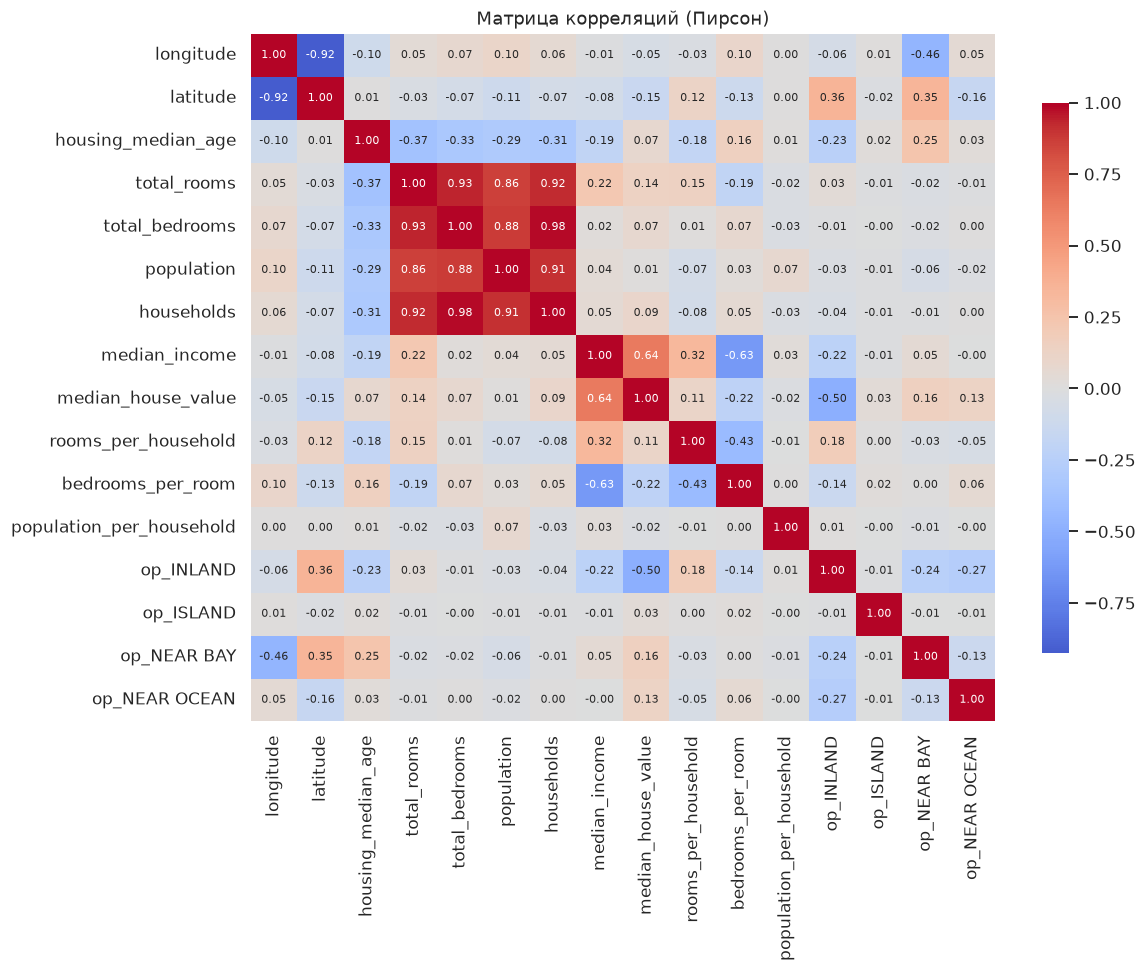

Корреляция с целевой переменной:
 median_income               0.643
op_INLAND                  -0.499
bedrooms_per_room          -0.216
op_NEAR BAY                 0.157
latitude                   -0.149
total_rooms                 0.142
op_NEAR OCEAN               0.135
rooms_per_household         0.109
households                  0.094
total_bedrooms              0.075
housing_median_age          0.069
longitude                  -0.046
op_ISLAND                   0.031
population_per_household   -0.021
population                  0.011
Name: median_house_value, dtype: float64


In [32]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Матрица корреляций (Пирсон)")
fig.tight_layout()
fig.savefig(FIG + "04_corr.png", bbox_inches="tight")
plt.show()

target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Корреляция с целевой переменной:\n", target_corr.round(3))
RES["target_corr"] = target_corr.round(3).to_dict()

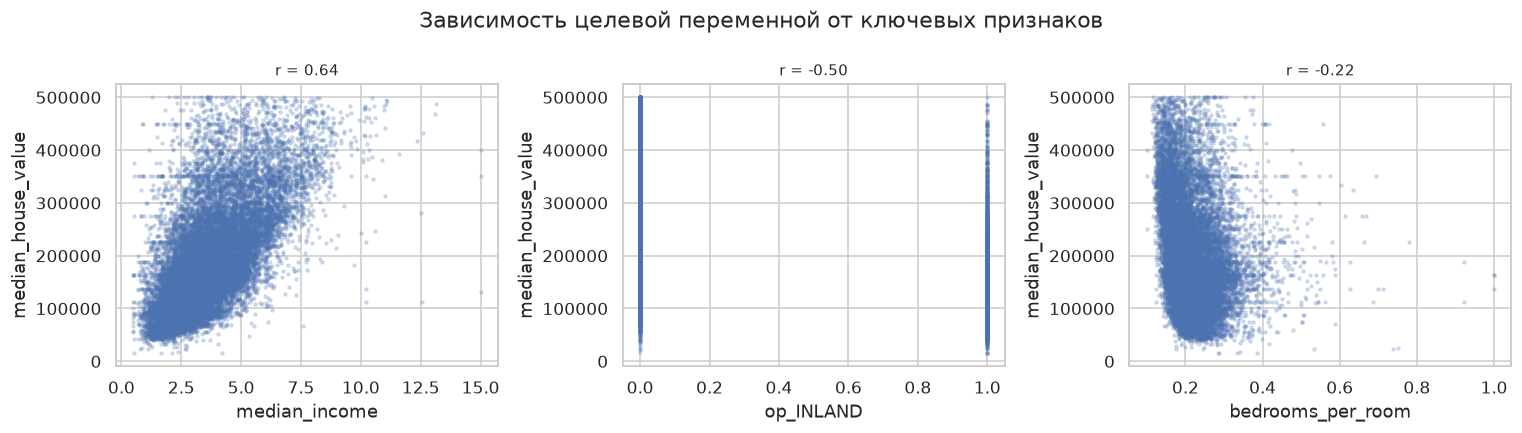

In [33]:
top3 = target_corr.abs().sort_values(ascending=False).index[:3]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, top3):
    ax.scatter(df[c], y, s=4, alpha=0.2, color="#4C72B0")
    ax.set_xlabel(c); ax.set_ylabel(TARGET)
    ax.set_title(f"r = {corr.loc[c, TARGET]:.2f}", fontsize=10)
fig.suptitle("Зависимость целевой переменной от ключевых признаков")
fig.tight_layout()
fig.savefig(FIG + "05_scatter.png", bbox_inches="tight")
plt.show()

In [34]:
def vif_table(X_df):
    Xs = StandardScaler().fit_transform(X_df)
    Xs = np.column_stack([np.ones(len(Xs)), Xs])
    return pd.DataFrame({
        "Признак": X_df.columns,
        "VIF": [variance_inflation_factor(Xs, i + 1) for i in range(X_df.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

vif = vif_table(X)
print(vif.round(2))
RES["vif"] = vif.round(2).to_dict("records")

                     Признак    VIF
0             total_bedrooms  50.92
1                 households  45.64
2                   latitude  20.23
3                total_rooms  19.46
4                  longitude  18.10
5                 population   7.01
6                  op_INLAND   2.91
7          bedrooms_per_room   2.85
8              median_income   2.38
9        rooms_per_household   1.84
10               op_NEAR BAY   1.54
11        housing_median_age   1.37
12             op_NEAR OCEAN   1.20
13  population_per_household   1.07
14                 op_ISLAND   1.00


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print("train:", X_train.shape, " test:", X_test.shape)
RES["split"] = {"train": list(X_train.shape), "test": list(X_test.shape)}

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

train: (15580, 15)  test: (3895, 15)


In [36]:
def evaluate(model, Xtr, ytr, Xte, yte, name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=cv, scoring="r2")
    cv_rmse = -cross_val_score(model, Xtr, ytr, cv=cv, scoring="neg_root_mean_squared_error")
    row = {
        "Модель": name,
        "RMSE": float(np.sqrt(mean_squared_error(yte, pred))),
        "R2": float(r2_score(yte, pred)),
        "MAPE, %": float(mean_absolute_percentage_error(yte, pred) * 100),
        "CV R2 (5-fold)": float(cv_r2.mean()),
        "CV RMSE (5-fold)": float(cv_rmse.mean()),
    }
    print(f"{name}: RMSE={row['RMSE']:.1f}  R2={row['R2']:.4f}  "
          f"MAPE={row['MAPE, %']:.2f}%  CV R2={row['CV R2 (5-fold)']:.4f}")
    return row, pred

results = []

In [37]:
lin = LinearRegression()
row_lin, pred_lin = evaluate(lin, X_train_s, y_train, X_test_s, y_test,
                             "Линейная регрессия (исходные признаки)")
results.append(row_lin)

coefs = pd.Series(lin.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("Коэффициенты (на стандартизованных данных):\n", coefs.round(1))
RES["coefs"] = coefs.round(1).to_dict()

Линейная регрессия (исходные признаки): RMSE=60019.3  R2=0.6281  MAPE=26.88%  CV R2=0.6138
Коэффициенты (на стандартизованных данных):
 median_income               64792.3
longitude                  -50834.6
latitude                   -49234.7
population                 -37533.3
households                  29904.3
op_INLAND                  -15983.4
bedrooms_per_room           14428.3
total_bedrooms              12350.1
housing_median_age          12156.6
rooms_per_household          4567.3
op_ISLAND                    2873.0
op_NEAR BAY                 -2527.3
op_NEAR OCEAN                1526.2
total_rooms                   324.0
population_per_household       51.6
dtype: float64


In [38]:
grid = GridSearchCV(Ridge(), {"alpha": np.logspace(-3, 4, 40)},
                    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
grid.fit(X_train_s, y_train)
best_alpha = grid.best_params_["alpha"]
print("Лучшее alpha:", round(best_alpha, 4))
RES["best_alpha"] = float(best_alpha)

row_ridge, pred_ridge = evaluate(Ridge(alpha=best_alpha), X_train_s, y_train,
                                 X_test_s, y_test, "Гребневая регрессия (исходные признаки)")
results.append(row_ridge)

Лучшее alpha: 70.1704
Гребневая регрессия (исходные признаки): RMSE=60038.2  R2=0.6278  MAPE=26.76%  CV R2=0.6143


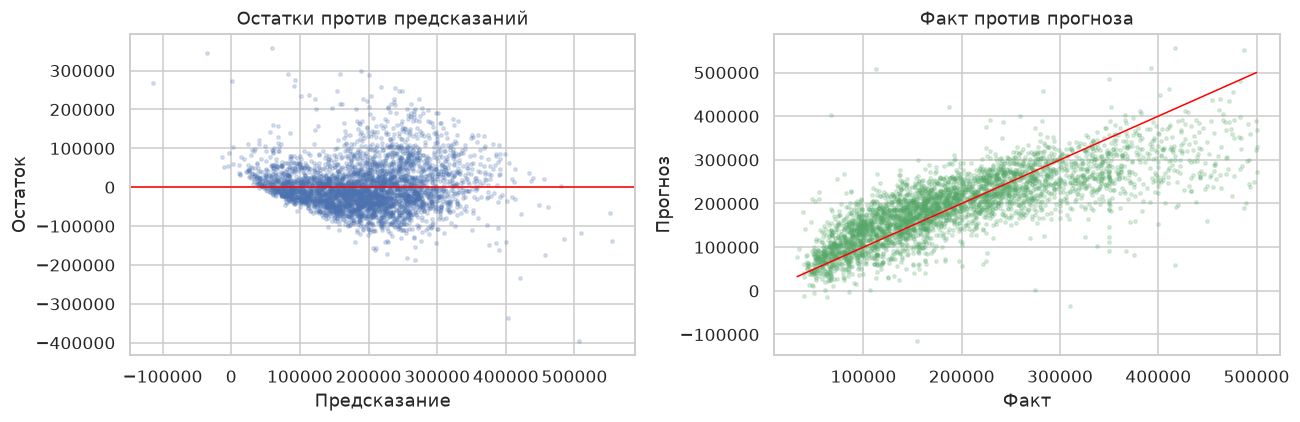

In [39]:
resid = y_test - pred_lin
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_lin, resid, s=5, alpha=0.2, color="#4C72B0")
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Предсказание"); axes[0].set_ylabel("Остаток")
axes[0].set_title("Остатки против предсказаний")
axes[1].scatter(y_test, pred_lin, s=5, alpha=0.2, color="#55A868")
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, color="red", lw=1)
axes[1].set_xlabel("Факт"); axes[1].set_ylabel("Прогноз")
axes[1].set_title("Факт против прогноза")
fig.tight_layout()
fig.savefig(FIG + "06_resid.png", bbox_inches="tight")
plt.show()

In [40]:
pca_full = PCA().fit(X_train_s)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n_comp = int(np.argmax(cum >= 0.95) + 1)
print("Доля объяснённой дисперсии:", np.round(evr, 3))
print("Накопленная:", np.round(cum, 3))
print("Компонент для 95 % дисперсии:", n_comp)
RES["evr"] = [float(v) for v in evr]
RES["cum"] = [float(v) for v in cum]
RES["n_comp"] = n_comp
RES["eigenvalues"] = [float(v) for v in pca_full.explained_variance_]

Доля объяснённой дисперсии: [0.264 0.155 0.132 0.101 0.067 0.067 0.065 0.048 0.042 0.029 0.017 0.008
 0.003 0.002 0.001]
Накопленная: [0.264 0.419 0.551 0.652 0.719 0.786 0.851 0.899 0.941 0.969 0.986 0.995
 0.998 0.999 1.   ]
Компонент для 95 % дисперсии: 10


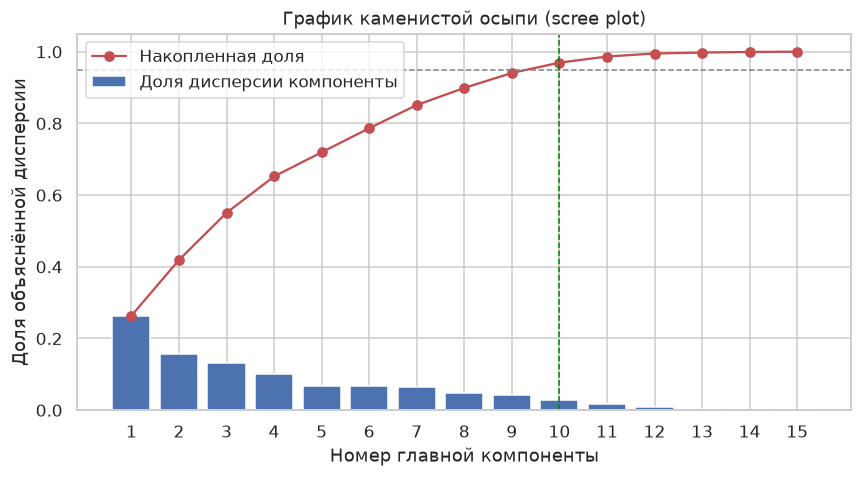

In [41]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.arange(1, len(evr) + 1)
ax.bar(xs, evr, color="#4C72B0", label="Доля дисперсии компоненты")
ax.plot(xs, cum, "o-", color="#C44E52", label="Накопленная доля")
ax.axhline(0.95, ls="--", color="gray", lw=1)
ax.axvline(n_comp, ls="--", color="green", lw=1)
ax.set_xlabel("Номер главной компоненты"); ax.set_ylabel("Доля объяснённой дисперсии")
ax.set_title("График каменистой осыпи (scree plot)")
ax.set_xticks(xs); ax.legend()
fig.tight_layout()
fig.savefig(FIG + "07_scree.png", bbox_inches="tight")
plt.show()

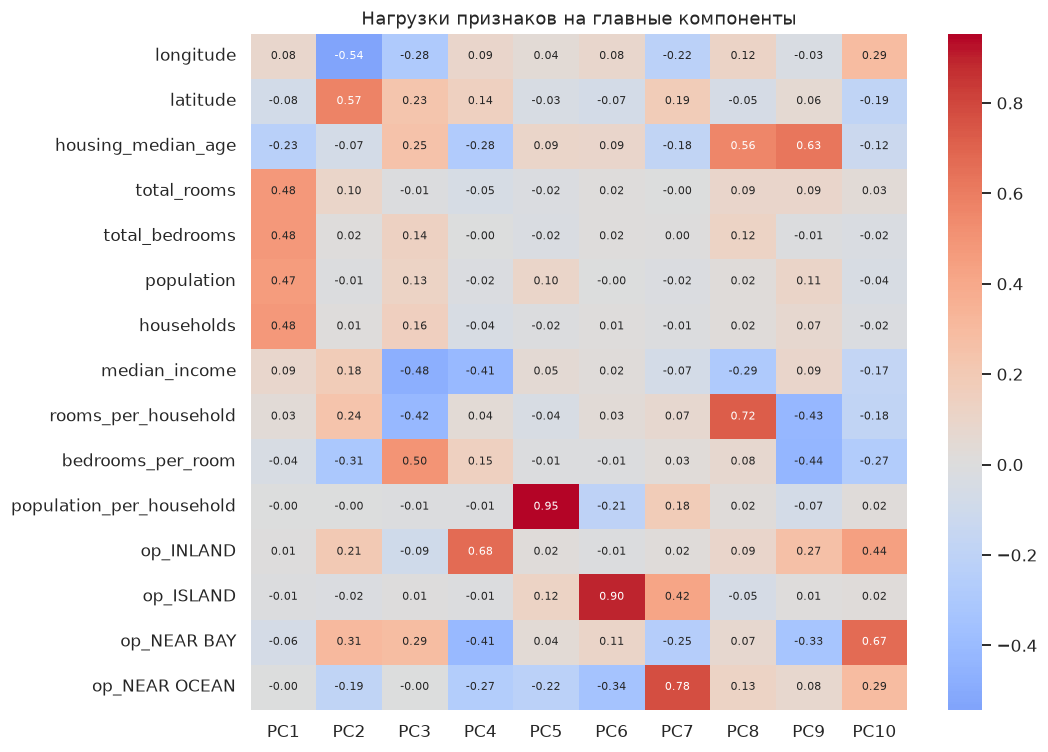

  Признак  VIF
0     PC1  1.0
1     PC2  1.0
2     PC3  1.0
3     PC4  1.0
4     PC5  1.0
5     PC6  1.0
6     PC7  1.0
7     PC8  1.0
8     PC9  1.0
9    PC10  1.0


In [42]:
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit(X_train_s)
X_train_p = pca.transform(X_train_s)
X_test_p = pca.transform(X_test_s)

loadings = pd.DataFrame(pca.components_.T,
                        index=X.columns,
                        columns=[f"PC{i+1}" for i in range(n_comp)])
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Нагрузки признаков на главные компоненты")
fig.tight_layout()
fig.savefig(FIG + "08_loadings.png", bbox_inches="tight")
plt.show()
RES["loadings"] = loadings.round(2).to_dict()

# VIF после PCA (компоненты ортогональны -> VIF ~ 1)
vif_pca = vif_table(pd.DataFrame(X_train_p, columns=loadings.columns))
print(vif_pca.round(3))
RES["vif_pca"] = vif_pca.round(3).to_dict("records")

In [43]:
row_lin_p, _ = evaluate(LinearRegression(), X_train_p, y_train, X_test_p, y_test,
                        f"Линейная регрессия (PCA, {n_comp} компонент)")
results.append(row_lin_p)

grid_p = GridSearchCV(Ridge(), {"alpha": np.logspace(-3, 4, 40)},
                      cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
grid_p.fit(X_train_p, y_train)
alpha_p = grid_p.best_params_["alpha"]
RES["best_alpha_pca"] = float(alpha_p)
row_ridge_p, _ = evaluate(Ridge(alpha=alpha_p), X_train_p, y_train, X_test_p, y_test,
                          f"Гребневая регрессия (PCA, {n_comp} компонент)")
results.append(row_ridge_p)

Линейная регрессия (PCA, 10 компонент): RMSE=66711.2  R2=0.5405  MAPE=29.19%  CV R2=0.5216
Гребневая регрессия (PCA, 10 компонент): RMSE=66724.3  R2=0.5403  MAPE=29.29%  CV R2=0.5219


In [44]:
metrics = pd.DataFrame(results).round(4)
print(metrics.to_string(index=False))
metrics.to_csv("metrics.csv", index=False, encoding="utf-8-sig")
RES["metrics"] = metrics.to_dict("records")

                                 Модель       RMSE     R2  MAPE, %  CV R2 (5-fold)  CV RMSE (5-fold)
 Линейная регрессия (исходные признаки) 60019.2578 0.6281  26.8798          0.6138        60574.0654
Гребневая регрессия (исходные признаки) 60038.2189 0.6278  26.7571          0.6143        60536.1986
 Линейная регрессия (PCA, 10 компонент) 66711.2136 0.5405  29.1910          0.5216        67436.0946
Гребневая регрессия (PCA, 10 компонент) 66724.3067 0.5403  29.2925          0.5219        67415.6595


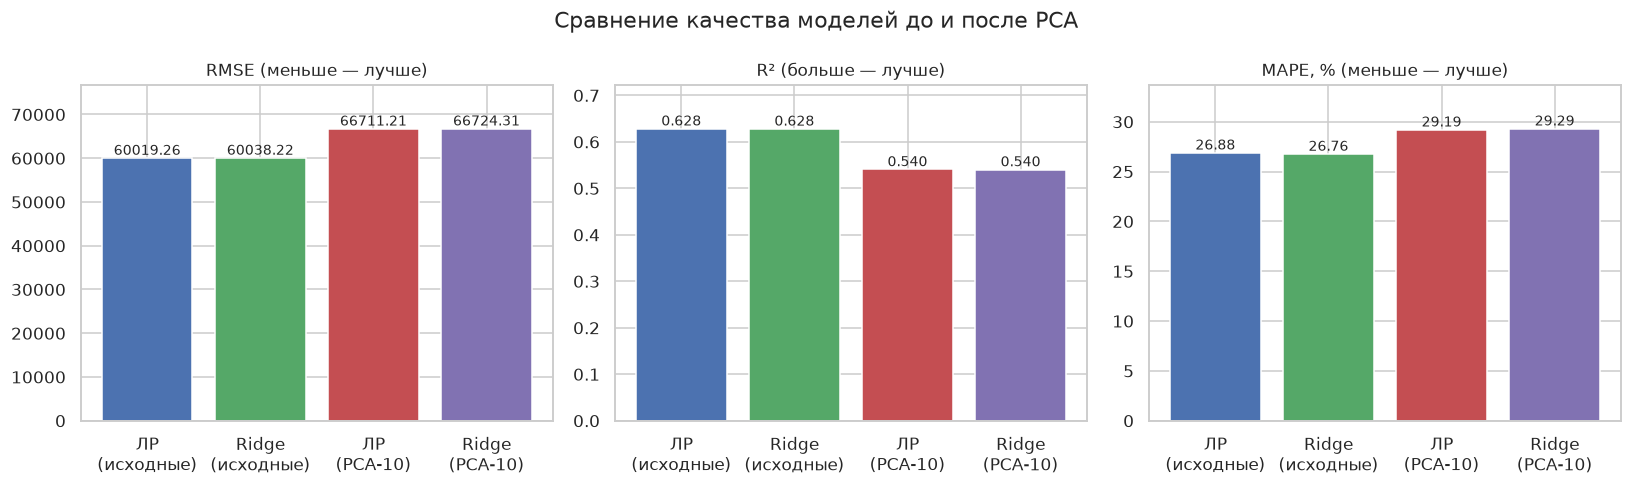

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
names = ["ЛР\n(исходные)", "Ridge\n(исходные)", f"ЛР\n(PCA-{n_comp})", f"Ridge\n(PCA-{n_comp})"]
for ax, col, ttl in zip(axes, ["RMSE", "R2", "MAPE, %"], ["RMSE (меньше — лучше)",
                                                          "R² (больше — лучше)",
                                                          "MAPE, % (меньше — лучше)"]):
    bars = ax.bar(names, metrics[col], color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
    ax.set_title(ttl, fontsize=11)
    ax.bar_label(bars, fmt="%.3f" if col == "R2" else "%.2f", fontsize=9)
    ax.margins(y=0.15)
fig.suptitle("Сравнение качества моделей до и после PCA")
fig.tight_layout()
fig.savefig(FIG + "09_metrics.png", bbox_inches="tight")
plt.show()

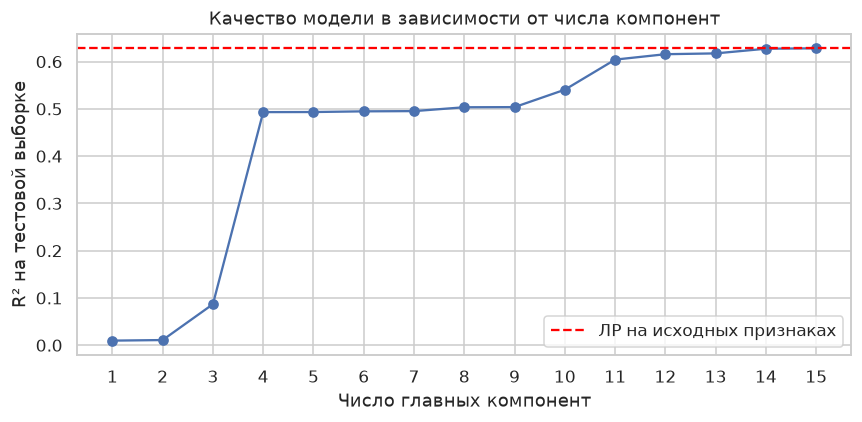

Готово.


In [46]:
scores = []
for k in range(1, X_train_s.shape[1] + 1):
    p = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train_s)
    m = LinearRegression().fit(p.transform(X_train_s), y_train)
    scores.append(r2_score(y_test, m.predict(p.transform(X_test_s))))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(scores) + 1), scores, "o-", color="#4C72B0")
ax.axhline(row_lin["R2"], ls="--", color="red", label="ЛР на исходных признаках")
ax.set_xlabel("Число главных компонент"); ax.set_ylabel("R² на тестовой выборке")
ax.set_title("Качество модели в зависимости от числа компонент")
ax.legend(); ax.set_xticks(range(1, len(scores) + 1))
fig.tight_layout()
fig.savefig(FIG + "10_r2_vs_k.png", bbox_inches="tight")
plt.show()
RES["r2_vs_k"] = [float(s) for s in scores]

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(RES, f, ensure_ascii=False, indent=1, default=str)
print("Готово.")